In [1]:
# ============================================================
# SUPPLY CHAIN INTELLIGENCE SYSTEM
# Notebook 5: Demand Forecasting & Reorder Alerts
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# ============================================================
# Load data
# ============================================================

processed_path = r'D:\Projects\End-to-end projects\8. Supply Chain Intelligence\Data\Processed'

df_inventory     = pd.read_csv(processed_path + r'\inventory_snapshots_clean.csv',
                               parse_dates=['snapshot_date'])
df_products      = pd.read_csv(processed_path + r'\products_clean.csv')
df_sales         = pd.read_csv(processed_path + r'\sales_orders_clean.csv',
                               parse_dates=['order_date'])
df_suppliers     = pd.read_csv(processed_path + r'\suppliers_clean.csv')
inventory_matrix = pd.read_csv(processed_path + r'\inventory_abc_xyz.csv')

print("✅ Data loaded successfully!")
print(f"Inventory Snapshots: {len(df_inventory):,} rows")
print(f"Date range: {df_inventory['snapshot_date'].min().date()} to {df_inventory['snapshot_date'].max().date()}")

✅ Data loaded successfully!
Inventory Snapshots: 15,750 rows
Date range: 2023-01-01 to 2024-12-29


In [3]:
# ============================================================
# STEP 1: Prepare weekly demand per SKU
# Aggregate across all warehouses
# ============================================================

# Weekly demand per SKU — sum across all warehouses
weekly_demand = df_inventory.groupby(
    ['snapshot_date', 'sku_id']
)['units_sold'].sum().reset_index()

weekly_demand.columns = ['ds', 'sku_id', 'y']

# Focus on A-category SKUs for forecasting
# These are the most important SKUs to get right
a_category_skus = inventory_matrix[
    inventory_matrix['abc_category'] == 'A'
]['sku_id'].tolist()

print(f"✅ Weekly demand prepared!")
print(f"Total weekly records:     {len(weekly_demand):,}")
print(f"A-Category SKUs to forecast: {len(a_category_skus)}")
print(f"\nSample weekly demand (first SKU):")
sample = weekly_demand[weekly_demand['sku_id'] == a_category_skus[0]].head(8)
print(sample.to_string(index=False))

✅ Weekly demand prepared!
Total weekly records:     5,250
A-Category SKUs to forecast: 23

Sample weekly demand (first SKU):
        ds sku_id   y
2023-01-01 SKU011 228
2023-01-08 SKU011 219
2023-01-15 SKU011 214
2023-01-22 SKU011 235
2023-01-29 SKU011 223
2023-02-05 SKU011 178
2023-02-12 SKU011 160
2023-02-19 SKU011 232


In [4]:
# ============================================================
# STEP 2: Prophet Forecasting
# Forecast next 12 weeks for top 10 A-category SKUs
# Prophet handles seasonality automatically
# ============================================================

from prophet import Prophet

forecast_results = []
forecast_plots   = {}

# Forecast top 10 A-category SKUs
top_skus_to_forecast = a_category_skus[:10]

print("🔄 Running Prophet forecasts...")
print(f"{'SKU':<10} {'Product':<30} {'Avg Weekly Demand':>18} {'Status'}")
print("-" * 70)

for sku_id in top_skus_to_forecast:
    # Get demand series for this SKU
    sku_data = weekly_demand[weekly_demand['sku_id'] == sku_id][['ds', 'y']].copy()
    sku_data = sku_data.sort_values('ds').reset_index(drop=True)

    # Need at least 10 data points for Prophet
    if len(sku_data) < 10:
        continue

    try:
        # Initialize Prophet
        model = Prophet(
            yearly_seasonality  = True,
            weekly_seasonality  = False,
            daily_seasonality   = False,
            seasonality_mode    = 'multiplicative',
            interval_width      = 0.80,
            changepoint_prior_scale = 0.05
        )

        # Add Indian festival seasonality (Diwali — Oct/Nov spike)
        model.add_seasonality(
            name   = 'diwali_season',
            period = 365.25,
            fourier_order = 5
        )

        # Fit model
        model.fit(sku_data)

        # Forecast next 12 weeks
        future   = model.make_future_dataframe(periods=12, freq='W')
        forecast = model.predict(future)

        # Store forecast
        forecast['sku_id'] = sku_id
        forecast_plots[sku_id] = {
            'historical': sku_data,
            'forecast':   forecast
        }

        # Get next 12 weeks forecast
        future_only = forecast[forecast['ds'] > sku_data['ds'].max()].copy()

        # Product name
        product_name = df_products[df_products['sku_id'] == sku_id]['product_name'].values[0]
        avg_demand   = sku_data['y'].mean()

        for _, row in future_only.iterrows():
            forecast_results.append({
                'sku_id':          sku_id,
                'product_name':    product_name,
                'forecast_date':   row['ds'].strftime('%Y-%m-%d'),
                'forecasted_units': max(0, round(row['yhat'], 0)),
                'lower_bound':     max(0, round(row['yhat_lower'], 0)),
                'upper_bound':     max(0, round(row['yhat_upper'], 0)),
            })

        print(f"{sku_id:<10} {product_name[:28]:<30} {avg_demand:>18.1f}  ✅")

    except Exception as e:
        print(f"{sku_id:<10} {'Error':<30} {str(e)[:30]}  ❌")

df_forecast = pd.DataFrame(forecast_results)
print(f"\n✅ Forecasting complete!")
print(f"Total forecast records: {len(df_forecast)}")

🔄 Running Prophet forecasts...
SKU        Product                         Avg Weekly Demand Status
----------------------------------------------------------------------


10:34:31 - cmdstanpy - INFO - Chain [1] start processing
10:34:32 - cmdstanpy - INFO - Chain [1] done processing
10:34:32 - cmdstanpy - INFO - Chain [1] start processing
10:34:33 - cmdstanpy - INFO - Chain [1] done processing


SKU011     Cold Press Coconut Oil 500ml                221.5  ✅


10:34:33 - cmdstanpy - INFO - Chain [1] start processing
10:34:33 - cmdstanpy - INFO - Chain [1] done processing


SKU016     Rose Water 200ml                            225.9  ✅


...

SKU035     Protein Shake Mix 500g                      268.1  ✅


10:34:35 - cmdstanpy - INFO - Chain [1] start processing
10:34:35 - cmdstanpy - INFO - Chain [1] done processing


SKU008     Salt 1kg                                    390.7  ✅


10:34:35 - cmdstanpy - INFO - Chain [1] start processing
10:34:35 - cmdstanpy - INFO - Chain [1] done processing


SKU022     Mathri 400g                                 335.5  ✅
SKU017     Hair Oil 200ml                              222.8  ✅

✅ Forecasting complete!
Total forecast records: 120


In [5]:
# ============================================================
# STEP 3: Reorder Alert System
# Compare forecasted demand vs current stock
# Flag SKUs that need reordering in next 7/14/30 days
# ============================================================

# Get current stock per SKU (latest snapshot)
current_stock = df_inventory.sort_values('snapshot_date').groupby('sku_id').last()[['closing_stock']].reset_index()
current_stock.columns = ['sku_id', 'current_stock']

# Get supplier lead times via product-supplier mapping
# Use average lead time across all suppliers as proxy
avg_lead_time = df_suppliers['avg_lead_time_days'].mean()

# Aggregate forecasted demand over next 7, 14, 30 days
reorder_alerts = []

for sku_id in top_skus_to_forecast:
    sku_forecast = df_forecast[df_forecast['sku_id'] == sku_id].copy()
    if len(sku_forecast) == 0:
        continue

    sku_forecast['forecast_date'] = pd.to_datetime(sku_forecast['forecast_date'])

    # Current stock
    stock_row = current_stock[current_stock['sku_id'] == sku_id]
    if len(stock_row) == 0:
        continue
    curr_stock = stock_row['current_stock'].values[0]

    # Product info
    prod_row     = df_products[df_products['sku_id'] == sku_id].iloc[0]
    product_name = prod_row['product_name']
    rop          = prod_row['reorder_point_units']
    moq          = prod_row['minimum_order_qty']
    unit_cost    = prod_row['unit_cost_inr']

    # Forecasted demand for next 7, 14, 30 days
    # Convert weekly forecast to daily (divide by 7)
    weekly_forecast_avg = sku_forecast['forecasted_units'].mean()
    daily_forecast_avg  = weekly_forecast_avg / 7

    demand_7d  = round(daily_forecast_avg * 7,  0)
    demand_14d = round(daily_forecast_avg * 14, 0)
    demand_30d = round(daily_forecast_avg * 30, 0)

    # Days of stock remaining
    days_of_stock = round(curr_stock / daily_forecast_avg, 1) if daily_forecast_avg > 0 else 999

    # Stockout date
    forecast_start = pd.Timestamp('2025-01-01')
    stockout_date  = forecast_start + pd.Timedelta(days=int(days_of_stock))

    # Reorder urgency
    if days_of_stock <= avg_lead_time:
        urgency = '🔴 URGENT — Order NOW'
    elif days_of_stock <= avg_lead_time * 1.5:
        urgency = '🟡 HIGH — Order within 7 days'
    elif days_of_stock <= avg_lead_time * 2:
        urgency = '🟢 MEDIUM — Order within 14 days'
    else:
        urgency = '✅ OK — Sufficient stock'

    # Reorder value
    reorder_value = moq * unit_cost

    reorder_alerts.append({
        'sku_id':           sku_id,
        'product_name':     product_name,
        'current_stock':    curr_stock,
        'reorder_point':    rop,
        'days_of_stock':    days_of_stock,
        'projected_stockout_date': stockout_date.strftime('%Y-%m-%d'),
        'demand_next_7d':   demand_7d,
        'demand_next_14d':  demand_14d,
        'demand_next_30d':  demand_30d,
        'recommended_moq':  moq,
        'reorder_value_inr': reorder_value,
        'urgency':          urgency
    })

df_reorder = pd.DataFrame(reorder_alerts).sort_values('days_of_stock')

print("✅ Reorder Alert System complete!")
print(f"\n{'='*80}")
print(f"REORDER ALERT DASHBOARD")
print(f"{'='*80}")
print(f"\n{'SKU':<8} {'Product':<28} {'Curr Stock':>10} {'Days Left':>10} {'Urgency'}")
print("-" * 80)
for _, row in df_reorder.iterrows():
    print(f"{row['sku_id']:<8} {row['product_name'][:26]:<28} {row['current_stock']:>10,.0f} {row['days_of_stock']:>10.1f}  {row['urgency']}")

✅ Reorder Alert System complete!

REORDER ALERT DASHBOARD

SKU      Product                      Curr Stock  Days Left Urgency
--------------------------------------------------------------------------------
SKU008   Salt 1kg                            411        7.8  🔴 URGENT — Order NOW
SKU017   Hair Oil 200ml                      417       14.0  🟡 HIGH — Order within 7 days
SKU016   Rose Water 200ml                    480       14.5  🟡 HIGH — Order within 7 days
SKU039   Rose Sherbet 750ml                  713       18.5  🟢 MEDIUM — Order within 14 days
SKU011   Cold Press Coconut Oil 500          691       22.2  🟢 MEDIUM — Order within 14 days
SKU022   Mathri 400g                       1,922       36.6  ✅ OK — Sufficient stock
SKU020   Face Scrub 100g                   1,407       48.3  ✅ OK — Sufficient stock
SKU033   Turmeric Latte 200g               2,451       60.3  ✅ OK — Sufficient stock
SKU014   Aloe Vera Gel 150g                1,690       61.0  ✅ OK — Sufficient stock
SKU0

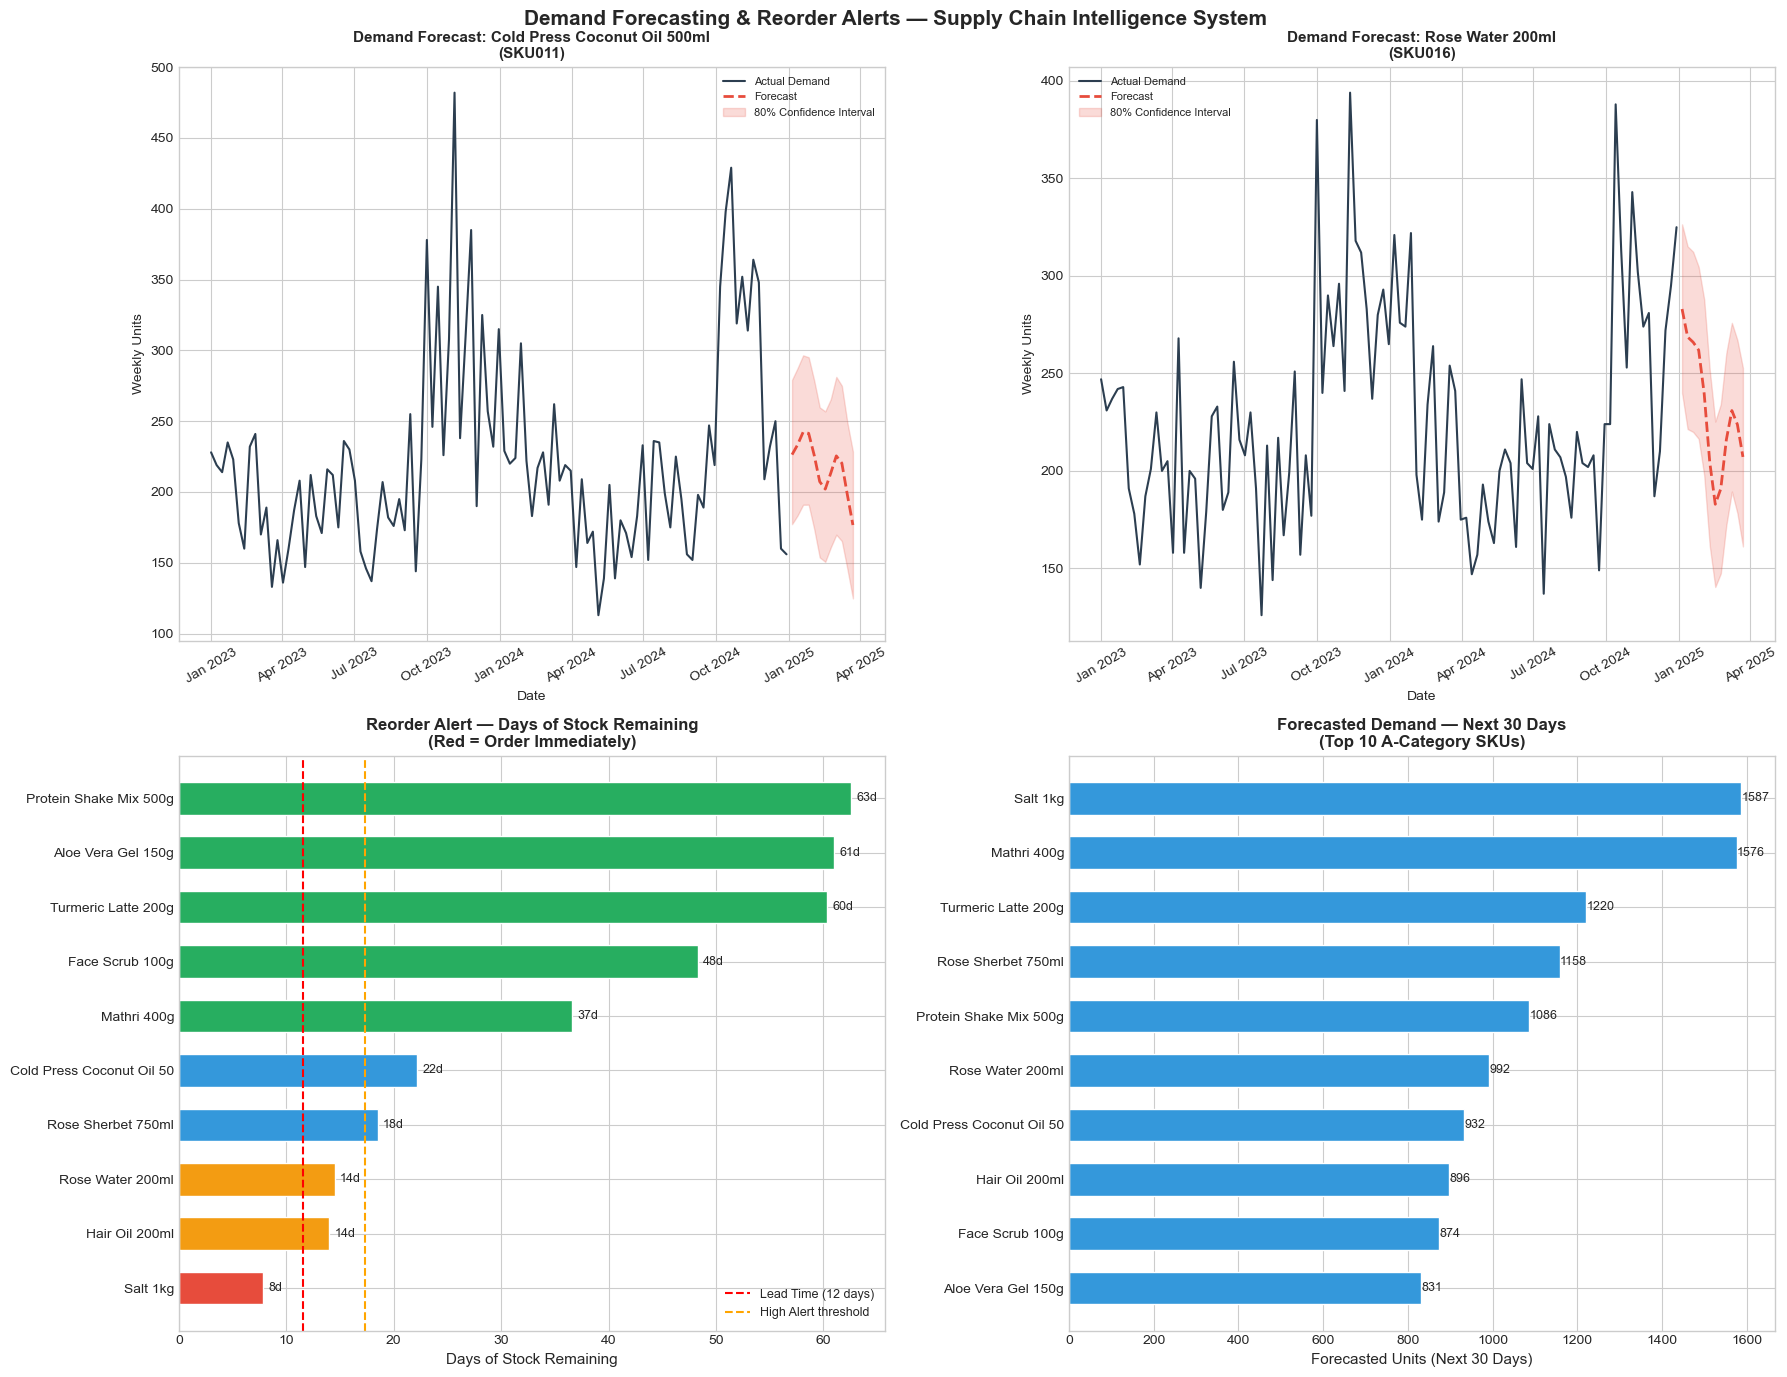

✅ Demand forecasting charts saved!


In [6]:
# ============================================================
# STEP 4: Demand Forecasting Visualizations
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Demand Forecasting & Reorder Alerts — Supply Chain Intelligence System',
             fontsize=15, fontweight='bold')

# ── Chart 1 & 2: Forecast plots for top 2 SKUs ──────────────
for idx, sku_id in enumerate(list(forecast_plots.keys())[:2]):
    ax = axes[0, idx]
    data     = forecast_plots[sku_id]
    hist     = data['historical']
    forecast = data['forecast']

    # Historical
    ax.plot(hist['ds'], hist['y'],
            color='#2c3e50', linewidth=1.5, label='Actual Demand', zorder=3)

    # Forecast
    future_mask = forecast['ds'] > hist['ds'].max()
    ax.plot(forecast[future_mask]['ds'],
            forecast[future_mask]['yhat'],
            color='#e74c3c', linewidth=2, linestyle='--', label='Forecast')

    # Confidence interval
    ax.fill_between(
        forecast[future_mask]['ds'],
        forecast[future_mask]['yhat_lower'],
        forecast[future_mask]['yhat_upper'],
        alpha=0.2, color='#e74c3c', label='80% Confidence Interval'
    )

    product_name = df_products[df_products['sku_id'] == sku_id]['product_name'].values[0]
    ax.set_title(f'Demand Forecast: {product_name[:30]}\n({sku_id})',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Date',          fontsize=10)
    ax.set_ylabel('Weekly Units',  fontsize=10)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

# ── Chart 3: Reorder Urgency Bar Chart ──────────────────────
ax3 = axes[1, 0]
urgency_colors = []
for u in df_reorder['urgency']:
    if 'URGENT' in u:
        urgency_colors.append('#e74c3c')
    elif 'HIGH' in u:
        urgency_colors.append('#f39c12')
    elif 'MEDIUM' in u:
        urgency_colors.append('#3498db')
    else:
        urgency_colors.append('#27ae60')

bars = ax3.barh(
    df_reorder['product_name'].str[:25],
    df_reorder['days_of_stock'],
    color=urgency_colors,
    edgecolor='white',
    height=0.6
)
ax3.axvline(x=avg_lead_time,       color='red',    linestyle='--',
            linewidth=1.5, label=f'Lead Time ({avg_lead_time:.0f} days)')
ax3.axvline(x=avg_lead_time * 1.5, color='orange', linestyle='--',
            linewidth=1.5, label='High Alert threshold')
ax3.set_xlabel('Days of Stock Remaining', fontsize=11)
ax3.set_title('Reorder Alert — Days of Stock Remaining\n(Red = Order Immediately)',
              fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)

for bar, days in zip(bars, df_reorder['days_of_stock']):
    ax3.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{days:.0f}d', va='center', fontsize=9)

# ── Chart 4: Forecasted Demand Next 30 Days ─────────────────
ax4 = axes[1, 1]
top_demand = df_reorder.sort_values('demand_next_30d', ascending=True).tail(10)
ax4.barh(
    top_demand['product_name'].str[:25],
    top_demand['demand_next_30d'],
    color='#3498db', edgecolor='white', height=0.6
)
ax4.set_xlabel('Forecasted Units (Next 30 Days)', fontsize=11)
ax4.set_title('Forecasted Demand — Next 30 Days\n(Top 10 A-Category SKUs)',
              fontsize=12, fontweight='bold')

for bar, val in zip(ax4.patches, top_demand['demand_next_30d']):
    ax4.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{val:.0f}', va='center', fontsize=9)

plt.tight_layout()
chart_path = r'D:\Projects\End-to-end projects\8. Supply Chain Intelligence\Dashboard\Screenshots\demand_forecast.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print("✅ Demand forecasting charts saved!")

In [7]:
# ============================================================
# Save forecast and reorder outputs
# ============================================================

df_forecast.to_csv(processed_path + r'\demand_forecast.csv',  index=False)
df_reorder.to_csv( processed_path + r'\reorder_alerts.csv',   index=False)

print("✅ All forecasting outputs saved!")
print(f"\n🎯 INTERVIEW-READY HEADLINE NUMBERS:")
print(f"{'='*55}")
print(f"SKUs Forecasted:              {len(top_skus_to_forecast)}")
print(f"Forecast Horizon:             12 weeks")
print(f"Avg Lead Time (days):         {avg_lead_time:.0f}")
urgent = df_reorder[df_reorder['urgency'].str.contains('URGENT')]
high   = df_reorder[df_reorder['urgency'].str.contains('HIGH')]
print(f"SKUs Needing Urgent Reorder:  {len(urgent)}")
print(f"SKUs on High Alert:           {len(high)}")
print(f"Total Reorder Value:          ₹{df_reorder['reorder_value_inr'].sum():,.0f}")
print(f"\n✅ Files saved:")
print(f"   demand_forecast.csv")
print(f"   reorder_alerts.csv")

✅ All forecasting outputs saved!

🎯 INTERVIEW-READY HEADLINE NUMBERS:
SKUs Forecasted:              10
Forecast Horizon:             12 weeks
Avg Lead Time (days):         12
SKUs Needing Urgent Reorder:  1
SKUs on High Alert:           2
Total Reorder Value:          ₹7,117,125

✅ Files saved:
   demand_forecast.csv
   reorder_alerts.csv
